In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

Giải thích thư viện:

1. import pandas as pd
Tên đầy đủ: Python Data Analysis Library.
Vai trò: Là công cụ mạnh mẽ nhất để làm việc với dữ liệu dạng bảng (giống như Excel nhưng bằng code).
Sử dụng để:
Đọc dữ liệu từ các file CSV, Excel, SQL.
Xem nhanh dữ liệu (hàm .head(), .info()).
Lọc cột, hàng, xử lý tên biến.
Ví dụ: df = pd.read_csv('train.csv').

2. import numpy as np
Tên đầy đủ: Numerical Python.
Vai trò: Thư viện chuyên về tính toán toán học, đặc biệt là làm việc với ma trận và mảng (array) nhiều chiều.
Sử dụng để:
Thực hiện các phép tính số học phức tạp trên toàn bộ bộ dữ liệu rất nhanh.
Xử lý các giá trị rỗng (np.nan).
Chuyển đổi dữ liệu về dạng mảng mà các thuật toán Machine Learning có thể hiểu được.

3. from sklearn.model_selection import train_test_split
Nguồn: Thư viện Scikit-learn (thư viện ML phổ biến nhất cho Python).
Vai trò: Hàm này dùng để chia bộ dữ liệu của bạn ra làm hai phần riêng biệt:
Tập Huấn luyện (Train set): Cho máy "học" để tìm ra quy luật.
Tập Kiểm tra (Test set): Để "thi thử". Máy sẽ dùng quy luật đã học để dự đoán và chúng ta so sánh với đáp án thật để xem máy giỏi đến đâu.
Mục đích: Đảm bảo mô hình có khả năng dự đoán tốt với dữ liệu mới, không bị "học vẹt".

4. from sklearn.linear_model import LinearRegression
Nguồn: Thư viện Scikit-learn.
Vai trò: Đây chính là "bộ não" hay thuật toán mà bạn chọn.
Cơ chế: Nó tìm kiếm mối quan hệ đường thẳng giữa các yếu tố đầu vào (diện tích, chất lượng...) và kết quả đầu ra (giá nhà).
Sử dụng để: Khởi tạo mô hình thông qua lệnh model = LinearRegression().

5. from sklearn.impute import SimpleImputer
Nguồn: Thư viện Scikit-learn (nhóm xử lý dữ liệu).
Vai trò: Dùng để xử lý dữ liệu bị thiếu (NaN).
Tại sao cần: Các thuật toán Machine Learning sẽ bị lỗi nếu dữ liệu có ô trống. SimpleImputer giúp bạn tự động điền vào những ô trống đó.
Cách điền: Có thể chọn điền bằng giá trị trung bình (mean), giá trị xuất hiện nhiều nhất (most_frequent), hoặc số trung vị (median) của cột đó.


In [53]:
# 1. Đọc dữ liệu từ đã donwload Kaggle
df = pd.read_csv('./data/train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


Lựa chọn 10 đặc trưng quan trọng:

1	OverallQual	    Chất lượng tổng thể (thang điểm 1-10)
2	GrLivArea	    Diện tích sàn sinh hoạt trên mặt đất (sqft)
3	GarageCars	    Sức chứa của gara (tính bằng số xe)
4	TotalBsmtSF	    Tổng diện tích tầng hầm (sqft)
5	1stFlrSF	    Diện tích tầng 1 (sqft)
6	FullBath	    Số lượng phòng tắm đầy đủ
7	YearBuilt	    Năm xây dựng gốc
8	YearRemodAdd	Năm cải tạo/tu sửa
9	TotRmsAbvGrd	Tổng số phòng trên mặt đất
10	Fireplaces	    Số lượng lò sưởi


In [54]:
# 1. Chọn 10 đặc trưng quan trọng 
features = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 
    'FullBath', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', 
    'TotRmsAbvGrd', 'Fireplaces'
]

X = df[features]
y = df['SalePrice']

In [55]:
X

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd,1stFlrSF,TotRmsAbvGrd,Fireplaces
0,7,1710,2,856,2,2003,2003,856,8,0
1,6,1262,2,1262,2,1976,1976,1262,6,1
2,7,1786,2,920,2,2001,2002,920,6,1
3,7,1717,3,756,1,1915,1970,961,7,1
4,8,2198,3,1145,2,2000,2000,1145,9,1
...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,2,953,2,1999,2000,953,7,1
1456,6,2073,2,1542,2,1978,1988,2073,7,2
1457,7,2340,1,1152,2,1941,2006,1188,9,2
1458,5,1078,1,1078,1,1950,1996,1078,5,0


In [56]:
# 2. Xử lý dữ liệu thiếu (Imputation)
# Xử lý dữ liệu thiếu cơ bản (điền giá trị 0 vào chỗ trống)
X = X.fillna(0)

In [57]:
# 3. Chia dữ liệu thành tập Huấn luyện (Train) và tập Kiểm tra (Test)
# 80% để học, 20% để kiểm tra độ chính xác
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
X_test

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd,1stFlrSF,TotRmsAbvGrd,Fireplaces
892,6,1068,1,1059,1,1963,2003,1068,6,0
1105,8,2622,2,1463,2,1994,1995,1500,9,2
413,5,1028,2,1008,1,1927,1950,1028,5,1
522,6,1664,2,1004,2,1947,1950,1004,7,2
1036,9,1620,3,1620,2,2007,2008,1620,6,1
...,...,...,...,...,...,...,...,...,...,...
479,4,1131,2,907,1,1937,2000,1131,7,0
1361,7,1530,2,1530,2,2005,2005,1530,7,1
802,7,1456,2,728,2,2005,2005,728,7,1
651,4,1510,1,755,1,1940,1950,755,7,1


In [59]:
y_test

892     154500
1105    325000
413     115000
522     159000
1036    315500
         ...  
479      89471
1361    260000
802     189000
651     108000
722     124500
Name: SalePrice, Length: 292, dtype: int64

In [60]:
# 4. Khởi tạo và huấn luyện mô hình Hồi quy tuyến tính
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [61]:
# 5. Đưa ra dự đoán trên tập Test
y_pred = model.predict(X_test)

In [62]:
# 6. Đánh giá mô hình
print(f"Độ chính xác (R2 Score): {model.score(X_test, y_test):.4f}")


Độ chính xác (R2 Score): 0.7981


In [63]:
y_test

892     154500
1105    325000
413     115000
522     159000
1036    315500
         ...  
479      89471
1361    260000
802     189000
651     108000
722     124500
Name: SalePrice, Length: 292, dtype: int64

In [64]:
y_pred

array([147742.1396646 , 300690.10969524, 121285.20590185, 178234.99714251,
       289594.37303282,  54494.71572212, 231701.64214331, 173442.18027709,
        53236.94556949, 119747.82748363, 154255.0311687 , 103737.42806895,
        82442.5400838 , 220241.51296013, 199683.06821797, 123345.1641187 ,
       219459.37084362, 130786.54936608, 123373.26536503, 215477.34700078,
       187509.28029699, 222224.13162694, 178048.89836263, 115407.63708628,
       209209.24662657, 169578.08833186, 207741.91003638,  87658.27142778,
       194181.92636353, 217567.89784001, 120549.75600581, 253116.72902849,
       212591.04808214,  82640.74314731, 272549.45696171, 149269.51635197,
       158872.27781782, 229247.43809548, 296746.16915339,  81142.65902827,
       143492.14571616, 249714.21920222, 111221.65146988, 303371.27667972,
       122092.56280053, 151635.31309212, 104105.83117053, 109201.9339704 ,
       343944.07229733, 127611.02219678,  99588.77283717, 205827.0279948 ,
       123888.22076854, 3

In [65]:
# 1. Tạo DataFrame từ y_test và y_pred
# Lưu ý: y_test.values được dùng để lấy mảng giá trị, bỏ qua index gốc của nó
comparison_df = pd.DataFrame({
    'Giá thực tế': y_test.values,
    'Giá dự đoán': y_pred.flatten() # flatten() để đảm bảo mảng 1 chiều
})

# 2. Tính thêm cột Sai lệch (Error) để dễ theo dõi
comparison_df['Chênh lệch'] = comparison_df['Giá thực tế'] - comparison_df['Giá dự đoán']

# 3. Tính thêm tỷ lệ sai số phần trăm (tùy chọn)
comparison_df['Sai số (%)'] = (abs(comparison_df['Chênh lệch']) / comparison_df['Giá thực tế']) * 100


In [66]:
# Hiển thị các dòng đầu tiên
print("Bảng so sánh Giá thực tế và Giá dự đoán:")
print(comparison_df.head(20))

Bảng so sánh Giá thực tế và Giá dự đoán:
    Giá thực tế    Giá dự đoán    Chênh lệch  Sai số (%)
0        154500  147742.139665   6757.860335    4.374020
1        325000  300690.109695  24309.890305    7.479966
2        115000  121285.205902  -6285.205902    5.465396
3        159000  178234.997143 -19234.997143   12.097482
4        315500  289594.373033  25905.626967    8.210975
5         75500   54494.715722  21005.284278   27.821569
6        311500  231701.642143  79798.357857   25.617450
7        146000  173442.180277 -27442.180277   18.796014
8         84500   53236.945569  31263.054431   36.997698
9        135500  119747.827484  15752.172516   11.625220
10       145000  154255.031169  -9255.031169    6.382780
11       130000  103737.428069  26262.571931   20.201978
12        81000   82442.540084  -1442.540084    1.780914
13       214000  220241.512960  -6241.512960    2.916595
14       181000  199683.068218 -18683.068218   10.322137
15       134500  123345.164119  11154.835881   

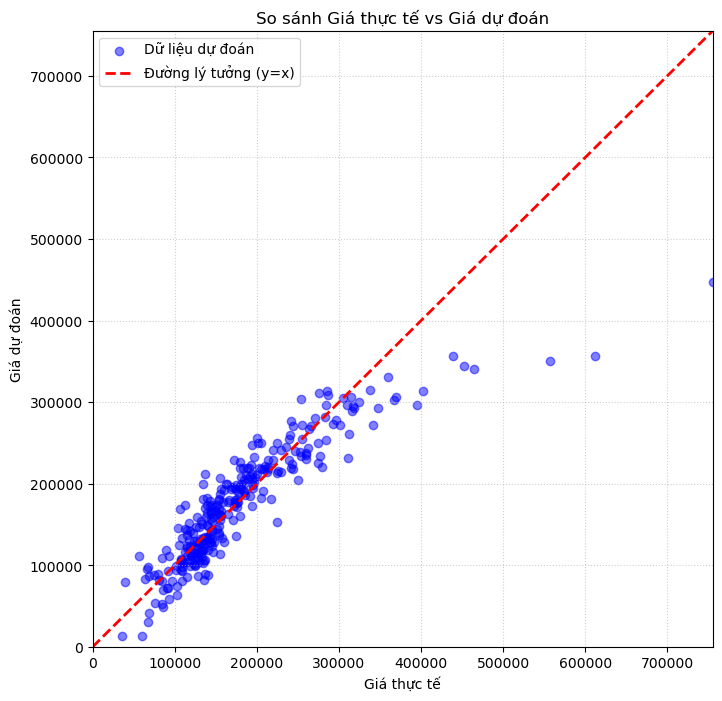

In [67]:
plt.figure(figsize=(8, 8)) # Tạo khung hình vuông để dễ quan sát

plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Dữ liệu dự đoán')

# Tìm giá trị lớn nhất của cả y_test và y_pred để thiết lập giới hạn trục
max_val = max(max(y_test), max(y_pred))
min_val = 0 # Đặt gốc tọa độ là 0

# Thiết lập giới hạn cho trục X và Y trùng nhau
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Vẽ đường chéo lý tưởng (y = x) - Nơi mà giá dự đoán bằng đúng giá thực tế
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Đường lý tưởng (y=x)')

plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title("So sánh Giá thực tế vs Giá dự đoán")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6) # Thêm lưới cho dễ nhìn
plt.show()

Trong mô hình Hồi quy tuyến tính (Linear Regression), các tham số w được gọi là Coefficients (Hệ số hồi quy) và hằng số 
b được gọi là Intercept (Hệ số chặn).
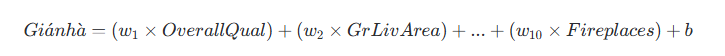

In [ ]:
# 1. Lấy hằng số b (Intercept)
print(f"Hằng số chặn (Intercept - b): {model.intercept_:,.2f}")

# 2. Lấy các hệ số w (Coefficients) gắn với từng tên cột
# Chúng ta tạo một DataFrame để hiển thị cho đẹp
coeff_df = pd.DataFrame({
    'Đặc trưng': features,
    'Hệ số (w)': model.coef_
})

print("\nBảng các hệ số w cho từng đặc trưng:")
print(coeff_df[['Đặc trưng', 'Hệ số (w)']].to_string(index=False))

Hằng số chặn (Intercept - b): -1,300,820.51

Bảng các hệ số w cho từng đặc trưng:
   Đặc trưng    Hệ số (w)
 OverallQual 18522.802542
   GrLivArea    43.779727
  GarageCars 14446.137329
 TotalBsmtSF    17.031864
    FullBath -6229.358017
   YearBuilt   279.188025
YearRemodAdd   349.697051
    1stFlrSF    10.599587
TotRmsAbvGrd   767.651992
  Fireplaces 10015.893685
